# Classification in Subsurface Engineering

Classification techniques predict discrete categories or classes rather than continuous values.

**Applications in Subsurface:**
- Classifying wells as high/low productivity
- Predicting risk levels (sand production, water production)
- Categorizing reservoir quality zones
- Identifying well suitability for different completion types

**Classification Methods Covered:**
1. **Logistic Regression:** Binary classification with probability output (0-1)
2. **Decision Boundaries:** Linear separators between classes
3. **Sigmoid Function:** Maps any value to probability (0-1) range

**Key Difference from Regression:**
- Regression: Predicts continuous values (e.g., 5.2, 10.7)
- Classification: Predicts discrete categories (e.g., High, Low)

---

## Classification: Well Productivity Assessment

C:\Users\NadirZeynalli\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\_param_validation.py:11: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.4)
  from scipy.sparse import csr_matrix, issparse
C:\Users\NadirZeynalli\AppData\Local\Temp\ipykernel_43052\220564539.py:33: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  scatter2 = ax1.scatter(KH[~labels], water_cut[~labels], color='red', s=100,
C:\Users\NadirZeynalli\AppData\Local\Temp\ipykernel_43052\220564539.py:65: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax2.scatter(KH[~labels], water_cut[~labels], color='darkred', s=100,


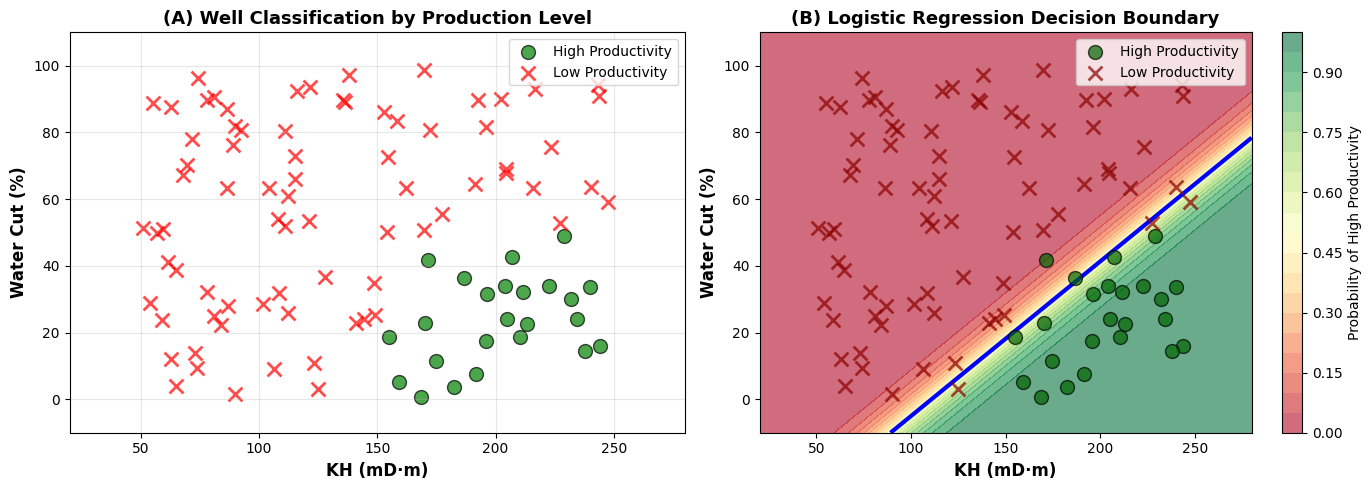

LOGISTIC REGRESSION MODEL RESULTS:
Model Accuracy: 95.00%
Model Coefficients: [KH: 0.099082, Water Cut: -0.213756]
Model Intercept: -10.979008

Decision Function: P(High) = 1 / (1 + exp(-(coef·X + intercept)))


In [1]:
"""
Logistic Regression: Well Productivity Classification
======================================================
Classifies wells as HIGH or LOW productivity based on:
- KH (Permeability × Thickness)
- Water Cut (%)

Decision Rule:
- HIGH Productivity: KH > 150 AND Water Cut < 50%
- LOW Productivity: Otherwise
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

np.random.seed(42)

# Generate training data
KH = np.random.uniform(50, 250, 100)
water_cut = np.random.uniform(0, 100, 100)

# Define classification rule
labels = (KH > 150) & (water_cut < 50)

# Plot 1: Data distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot with class labels
scatter1 = ax1.scatter(KH[labels], water_cut[labels], color='green', s=100, 
                       alpha=0.7, edgecolors='black', label='High Productivity', marker='o')
scatter2 = ax1.scatter(KH[~labels], water_cut[~labels], color='red', s=100, 
                       alpha=0.7, edgecolors='black', label='Low Productivity', marker='x', linewidth=2)

ax1.set_xlabel("KH (mD·m)", fontsize=12, fontweight='bold')
ax1.set_ylabel("Water Cut (%)", fontsize=12, fontweight='bold')
ax1.set_title("(A) Well Classification by Production Level", fontsize=13, fontweight='bold')
ax1.set_xlim(20, 280)
ax1.set_ylim(-10, 110)
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(True, alpha=0.3)

# Fit logistic regression model
X = np.column_stack((KH, water_cut))
y = labels.astype(int)
model = LogisticRegression(random_state=42)
model.fit(X, y)

# Calculate model accuracy
predictions = model.predict(X)
accuracy = accuracy_score(y, predictions)

# Create decision boundary
x_range = np.linspace(20, 280, 200)
y_range = np.linspace(-10, 110, 200)
X_grid, Y_grid = np.meshgrid(x_range, y_range)
Z = model.predict_proba(np.column_stack([X_grid.ravel(), Y_grid.ravel()]))[:, 1]
Z = Z.reshape(X_grid.shape)

# Plot decision boundary on second subplot
contour = ax2.contourf(X_grid, Y_grid, Z, levels=20, cmap='RdYlGn', alpha=0.6)
ax2.scatter(KH[labels], water_cut[labels], color='darkgreen', s=100, 
           alpha=0.7, edgecolors='black', label='High Productivity', marker='o', zorder=3)
ax2.scatter(KH[~labels], water_cut[~labels], color='darkred', s=100, 
           alpha=0.7, edgecolors='black', label='Low Productivity', marker='x', linewidth=2, zorder=3)
ax2.contour(X_grid, Y_grid, Z, levels=[0.5], colors='blue', linewidths=3, zorder=2)

ax2.set_xlabel("KH (mD·m)", fontsize=12, fontweight='bold')
ax2.set_ylabel("Water Cut (%)", fontsize=12, fontweight='bold')
ax2.set_title("(B) Logistic Regression Decision Boundary", fontsize=13, fontweight='bold')
ax2.set_xlim(20, 280)
ax2.set_ylim(-10, 110)
ax2.legend(loc='upper right', fontsize=10)

cbar = plt.colorbar(contour, ax=ax2)
cbar.set_label('Probability of High Productivity', fontsize=10)

plt.tight_layout()
plt.show()

print("LOGISTIC REGRESSION MODEL RESULTS:")
print("=" * 70)
print(f"Model Accuracy: {accuracy:.2%}")
print(f"Model Coefficients: [KH: {model.coef_[0][0]:.6f}, Water Cut: {model.coef_[0][1]:.6f}]")
print(f"Model Intercept: {model.intercept_[0]:.6f}")
print("\nDecision Function: P(High) = 1 / (1 + exp(-(coef·X + intercept)))")
print("=" * 70)

### Sand Risk Classification

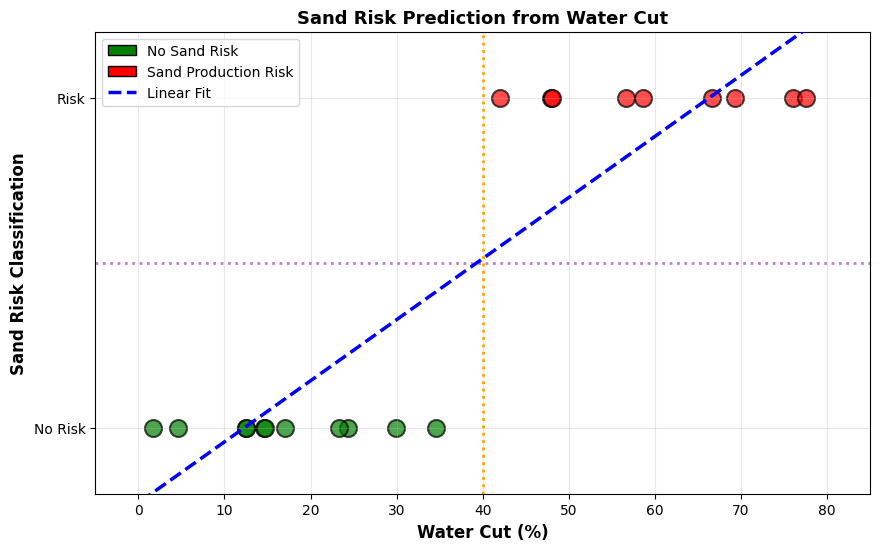

SAND RISK CLASSIFICATION RESULTS:
Classification Rule: Risk = 0.0185 × WC + -0.2280
R² Score: 0.7974

Interpretation:
  • Water Cut < 40%: LOW sand production risk  (Green)
  • Water Cut ≥ 40%: HIGH sand production risk (Red)

Risk Level Breakdown:
  • Low Risk Wells: 11 (55.0%)
  • High Risk Wells: 9 (45.0%)


In [3]:
"""
Binary Classification: Sand Risk Assessment
=============================================
Predicts sand risk (0=No Risk, 1=Risk) based on water cut percentage.

Real-World Context:
- High water cut indicates longer water-producing intervals
- More water production = more sand movement potential
- Sand production damages downhole equipment and surface facilities
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

np.random.seed(42)

# Generate data
water_cut = np.random.uniform(0, 80, 20)
sand_risk = (water_cut > 40).astype(int)  # Risk threshold at 40% WC

# Fit linear regression to probability
model = LinearRegression()
model.fit(water_cut.reshape(-1, 1), sand_risk)
predicted_risk = model.predict(water_cut.reshape(-1, 1))
r2 = r2_score(sand_risk, predicted_risk)

# Create visualization
fig, ax = plt.subplots(figsize=(10, 6))

# Plot points colored by actual risk
for wc, risk in zip(water_cut, sand_risk):
    color = 'red' if risk == 1 else 'green'
    label = 'Sand Risk' if risk == 1 else 'No Risk'
    ax.scatter(wc, risk, color=color, s=150, alpha=0.7, edgecolors='black', linewidth=1.5)

# Add regression line
wc_smooth = np.linspace(-5, 85, 100)
risk_pred = model.predict(wc_smooth.reshape(-1, 1))
ax.plot(wc_smooth, risk_pred, 'b--', linewidth=2.5, label='Linear Fit', zorder=3)

# Add threshold line
ax.axvline(x=40, color='orange', linestyle=':', linewidth=2, label='Risk Threshold (40% WC)', zorder=2)
ax.axhline(y=0.5, color='purple', linestyle=':', linewidth=2, alpha=0.5, zorder=1)

ax.set_yticks([0, 1])
ax.set_yticklabels(['No Risk', 'Risk'])
ax.set_xlim(-5, 85)
ax.set_ylim(-0.2, 1.2)
ax.set_xlabel("Water Cut (%)", fontsize=12, fontweight='bold')
ax.set_ylabel("Sand Risk Classification", fontsize=12, fontweight='bold')
ax.set_title("Sand Risk Prediction from Water Cut", fontsize=13, fontweight='bold')

# Create custom legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='green', edgecolor='black', label='No Sand Risk'),
    Patch(facecolor='red', edgecolor='black', label='Sand Production Risk'),
    ax.get_lines()[0]  # Blue line
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=10)

ax.grid(True, alpha=0.3)
# ax.tight_layout()
plt.show()

print("SAND RISK CLASSIFICATION RESULTS:")
print("=" * 70)
print(f"Classification Rule: Risk = {model.coef_[0]:.4f} × WC + {model.intercept_:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"\nInterpretation:")
print(f"  • Water Cut < 40%: LOW sand production risk  (Green)")
print(f"  • Water Cut ≥ 40%: HIGH sand production risk (Red)")
print(f"\nRisk Level Breakdown:")
low_risk = sum(sand_risk == 0)
high_risk = sum(sand_risk == 1)
print(f"  • Low Risk Wells: {low_risk} ({low_risk/len(sand_risk)*100:.1f}%)")
print(f"  • High Risk Wells: {high_risk} ({high_risk/len(sand_risk)*100:.1f}%)")
print("=" * 70)

### Sigmoid Function

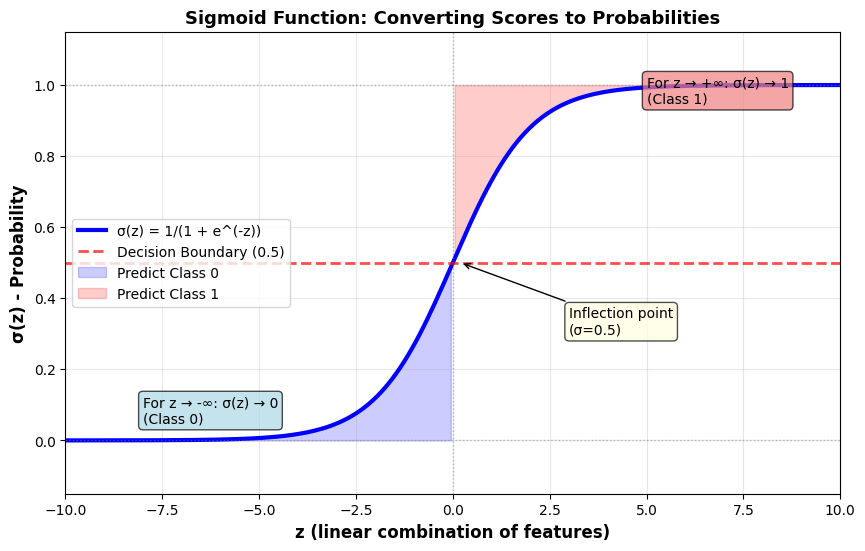

SIGMOID FUNCTION PROPERTIES:
Mathematical Definition: σ(z) = 1 / (1 + e^(-z))

Key Characteristics:
  • Always outputs values between 0 and 1
  • Smooth S-shaped curve (hence 'sigmoid')
  • σ(0) = 0.5 (decision boundary)
  • σ(-z) = 1 - σ(z) (symmetric around 0.5)
  • Monotonically increasing

Applications:
  • Logistic Regression probability output
  • Activation function in neural networks
  • Risk scoring (0-1 scale)


In [5]:
"""
Sigmoid Function: The Heart of Logistic Regression
===================================================
σ(z) = 1 / (1 + e^(-z))

Properties:
- Maps any real number to range [0, 1]
- Smooth, differentiable curve
- Perfect for converting predictions to probabilities
- Used extensively in neural networks

In classification context:
- σ(z) = P(Class 1 | Features)
- If σ(z) > 0.5, predict Class 1
- If σ(z) ≤ 0.5, predict Class 0
"""

import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    """Sigmoid activation function"""
    return 1 / (1 + np.exp(-z))

# Generate x values
x = np.linspace(-10, 10, 200)
y = sigmoid(x)

# Create figure with annotations
fig, ax = plt.subplots(figsize=(10, 6))

# Plot sigmoid curve
ax.plot(x, y, 'b-', linewidth=3, label='σ(z) = 1/(1 + e^(-z))')

# Add horizontal reference lines
ax.axhline(y=0.5, color='red', linestyle='--', linewidth=2, label='Decision Boundary (0.5)', alpha=0.7)
ax.axhline(y=0, color='gray', linestyle=':', linewidth=1, alpha=0.5)
ax.axhline(y=1, color='gray', linestyle=':', linewidth=1, alpha=0.5)

# Add vertical reference line at z=0
ax.axvline(x=0, color='gray', linestyle=':', linewidth=1, alpha=0.5)

# Annotations
ax.annotate('For z → -∞: σ(z) → 0\n(Class 0)', xy=(-8, 0.05), fontsize=10,
            bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))
ax.annotate('For z → +∞: σ(z) → 1\n(Class 1)', xy=(5, 0.95), fontsize=10,
            bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.7))
ax.annotate('Inflection point\n(σ=0.5)', xy=(0.2, 0.5), xytext=(3, 0.3),
            fontsize=10, arrowprops=dict(arrowstyle='->', color='black'),
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7))

# Add shading for class regions
ax.fill_between(x, 0, y, where=(y<=0.5), alpha=0.2, color='blue', label='Predict Class 0')
ax.fill_between(x, y, 1, where=(y>0.5), alpha=0.2, color='red', label='Predict Class 1')

ax.set_xlim(-10, 10)
ax.set_ylim(-0.15, 1.15)
ax.set_xlabel("z (linear combination of features)", fontsize=12, fontweight='bold')
ax.set_ylabel("σ(z) - Probability", fontsize=12, fontweight='bold')
ax.set_title("Sigmoid Function: Converting Scores to Probabilities", fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10, loc='center left')
# ax.tight_layout()
plt.show()

print("SIGMOID FUNCTION PROPERTIES:")
print("=" * 70)
print("Mathematical Definition: σ(z) = 1 / (1 + e^(-z))")
print("\nKey Characteristics:")
print("  • Always outputs values between 0 and 1")
print("  • Smooth S-shaped curve (hence 'sigmoid')")
print("  • σ(0) = 0.5 (decision boundary)")
print("  • σ(-z) = 1 - σ(z) (symmetric around 0.5)")
print("  • Monotonically increasing")
print("\nApplications:")
print("  • Logistic Regression probability output")
print("  • Activation function in neural networks")
print("  • Risk scoring (0-1 scale)")
print("=" * 70)

### Rock Properties: Porosity vs Permeability

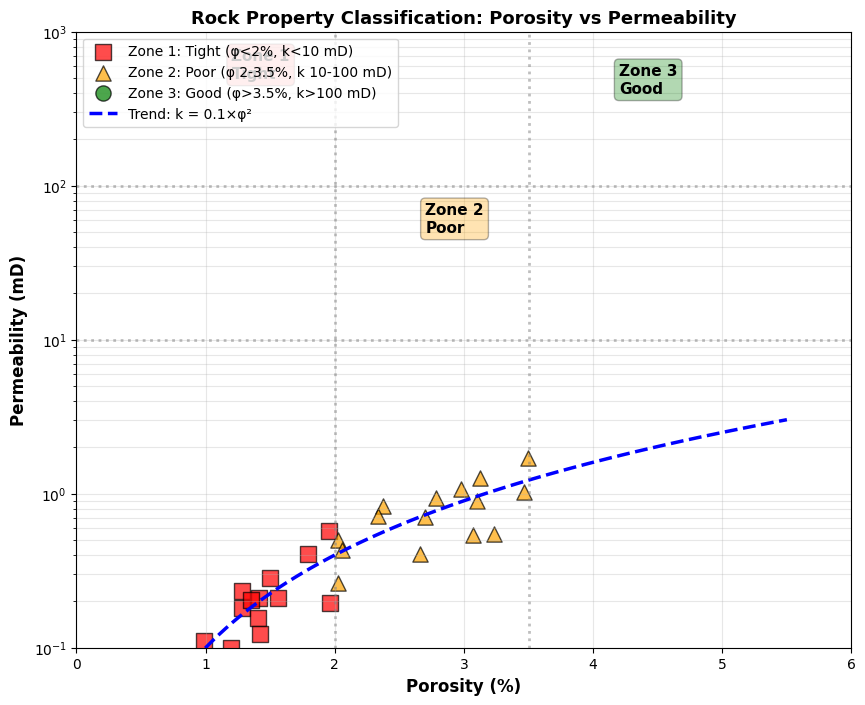

ROCK PROPERTY ANALYSIS:
Porosity Range: 0.60% - 5.35%
Permeability Range: 0.03 - 3.52 mD

Zone Distribution:
  • Tight (Zone 1): 19 samples
  • Poor (Zone 2): 15 samples
  • Good (Zone 3): 0 samples

Correlation: Porosity-Permeability relationship ~φ²


In [9]:
"""
Rock Properties Classification: Porosity vs Permeability
=========================================================
Archibald's Porosity-Permeability Relationship

General trend in clastic reservoirs:
- Higher porosity often correlates with higher permeability
- But relationship is NOT perfectly linear
- Cementation and clay content affect permeability significantly

Classification scheme (example):
- Zone 1: φ<5%, k<1 mD  (Tight)
- Zone 2: φ<15%, k<100 mD (Poor)
- Zone 3: φ>15%, k>100 mD (Good)
"""

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Generate realistic porosity-permeability data
# With scatter and non-linear trends
porosity = np.random.uniform(0.5, 5.5, 50)

# Relationship: k ≈ k₀ × φ^n (typical power law)
permeability_base = 0.1 * (porosity ** 2)
permeability = permeability_base * np.random.uniform(0.5, 1.5, 50)  # Add scatter

# Define zones
zone1 = (porosity < 2) & (permeability < 10)
zone2 = ((porosity >= 2) & (porosity < 3.5)) | ((permeability >= 10) & (permeability < 100))
zone3 = (porosity >= 3.5) & (permeability >= 100)

# Create classification boundaries
fig, ax = plt.subplots(figsize=(10, 8))

# Plot data points colored by zone
ax.scatter(porosity[zone1], permeability[zone1], s=120, color='red', alpha=0.7, 
          edgecolors='black', label='Zone 1: Tight (φ<2%, k<10 mD)', marker='s')
ax.scatter(porosity[zone2], permeability[zone2], s=120, color='orange', alpha=0.7, 
          edgecolors='black', label='Zone 2: Poor (φ 2-3.5%, k 10-100 mD)', marker='^')
ax.scatter(porosity[zone3], permeability[zone3], s=120, color='green', alpha=0.7, 
          edgecolors='black', label='Zone 3: Good (φ>3.5%, k>100 mD)', marker='o')

# Add trend line
phi_smooth = np.linspace(0.5, 5.5, 100)
k_trend = 0.1 * (phi_smooth ** 2)
ax.plot(phi_smooth, k_trend, 'b--', linewidth=2.5, label='Trend: k = 0.1×φ²', zorder=2)

# Add zone boundaries
ax.axvline(x=2, color='gray', linestyle=':', linewidth=2, alpha=0.5)
ax.axvline(x=3.5, color='gray', linestyle=':', linewidth=2, alpha=0.5)
ax.axhline(y=10, color='gray', linestyle=':', linewidth=2, alpha=0.5)
ax.axhline(y=100, color='gray', linestyle=':', linewidth=2, alpha=0.5)

ax.text(1.2, 500, 'Zone 1\nTight', fontsize=11, fontweight='bold', 
       bbox=dict(boxstyle='round', facecolor='red', alpha=0.3))
ax.text(2.7, 50, 'Zone 2\nPoor', fontsize=11, fontweight='bold', 
       bbox=dict(boxstyle='round', facecolor='orange', alpha=0.3))
ax.text(4.2, 400, 'Zone 3\nGood', fontsize=11, fontweight='bold', 
       bbox=dict(boxstyle='round', facecolor='green', alpha=0.3))

ax.set_xlabel("Porosity (%)", fontsize=12, fontweight='bold')
ax.set_ylabel("Permeability (mD)", fontsize=12, fontweight='bold')
ax.set_title("Rock Property Classification: Porosity vs Permeability", fontsize=13, fontweight='bold')
ax.set_xlim(0, 6)
ax.set_yscale('log')
ax.set_ylim(0.1, 1000)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3, which='both')
# plt.tight_layout()
plt.show()

print("ROCK PROPERTY ANALYSIS:")
print("=" * 70)
print(f"Porosity Range: {porosity.min():.2f}% - {porosity.max():.2f}%")
print(f"Permeability Range: {permeability.min():.2f} - {permeability.max():.2f} mD")
print(f"\nZone Distribution:")
print(f"  • Tight (Zone 1): {sum(zone1)} samples")
print(f"  • Poor (Zone 2): {sum(zone2)} samples")
print(f"  • Good (Zone 3): {sum(zone3)} samples")
print(f"\nCorrelation: Porosity-Permeability relationship ~φ²")
print("=" * 70)